# 19 â€” v03c Validation (bug fixes + turbid tracers)

Validates v03c run (completed 2026-04-23 on EDITO, 12h wallclock for 9 days of sim).

**v03c brings three fixes over v03b** â€” documented in [docs/progress_report_2026-04-22.md](../docs/progress_report_2026-04-22.md):

1. `iniWithNudge = 0` â€” XYZ hypersaline 42 ppt actually applied (v03b had `=2`, which made FM read initial sal from CMEMS nudge file)
2. `mapInterval = 900` â€” 15 min map output (was 30 min)
3. Two turbid tracers on day-3 pulse (Birgi airport + Trapani saltpans), replacing the broken `Tracer1` of v03b

**Known non-fix carried over**: waves stay quasi-constant. Pre-existing HDF5 error on SWAN re-opening com.nc means only the 1st wave iteration writes back. Investigation deferred.

Structure:
1. Setup + load
2. Sanity ranges
3. Water level vs in-situ
4. Wave fields (confirm constant)
5. **Salinity â€” fix verification** (initial = 42 ppt in lagoon?)
6. **Turbid tracers â€” dispersion check** (day-3 pulse)
7. v03b â†’ v03c delta
8. Summary

## 1. Setup + load his.nc

Only `_0000_his.nc` exists in the EDITO output â€” FM consolidates station data to partition 0 when it fits, so no merging needed.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

project_root = Path.cwd().parent
v03c_dir  = project_root / 'model' / 'dflowfm_v03c'
out_dir   = v03c_dir / 'output'
fig_dir   = project_root / 'figures'
proc_dir  = project_root / 'data' / 'processed'
insitu_dir = proc_dir

his_file = out_dir / 'Stagnone_dxy01_15m_0000_his.nc'
print(f'Loading {his_file.name} ({his_file.stat().st_size/1e6:.1f} MB)')
ds = xr.open_dataset(his_file)
print(f'Time range: {str(ds.time.values[0])[:19]} â†’ {str(ds.time.values[-1])[:19]}  ({ds.sizes["time"]} steps)')

# Station names (utf-8 decoded)
station_names = [s.decode().strip() if isinstance(s, bytes) else str(s).strip()
                 for s in ds.station_name.values]
print(f'Stations ({len(station_names)}): {station_names}')

# Helper to pick a station by name
def at(var, st):
    """Extract a variable at station `st` (returns surface layer if 3D)."""
    i = station_names.index(st)
    da = ds[var].isel(station=i)
    # Surface layer for 3D vars
    if 'laydim' in da.dims:
        da = da.isel(laydim=-1)
    return da

print()
print('Lateral discharge stations:')
if 'lateral_name' in ds:
    for i in range(ds.sizes['lateral']):
        lid = ds.lateral_name.values[i]
        lid = lid.decode().strip() if isinstance(lid, bytes) else str(lid).strip()
        print(f'  [{i}] {lid}')

Loading Stagnone_dxy01_15m_0000_his.nc (19.4 MB)


Time range: 2025-07-01T00:00:00 â†’ 2025-07-10T00:00:00  (1297 steps)
Stations (7): ['AltaVilaEst', 'BocaNord', 'BocaSud', 'ObservationPoint01', 'C1_Central', 'C2_NorthCenter', 'C3_SouthCenter']

Lateral discharge stations:
  [0] turbid_airport
  [1] turbid_saltpans


## 2. Sanity â€” physical ranges

Quick scan: min/median/max across all stations + all times. Spot anomalies (NaN, extreme values, zero variance) before any analysis.

In [2]:
def stats_line(name, da, expected):
    if da is None or da.size == 0:
        print(f'{name:25s}  NOT AVAILABLE')
        return
    a = da.values.ravel()
    finite = a[np.isfinite(a)]
    if finite.size == 0:
        print(f'{name:25s}  all NaN')
        return
    lo, hi = np.percentile(finite, [1, 99])
    std = finite.std()
    print(f'{name:25s}  min={finite.min():>8.3f}  p1={lo:>8.3f}  '
          f'median={np.median(finite):>8.3f}  p99={hi:>8.3f}  max={finite.max():>8.3f}  '
          f'std={std:>7.3f}  | {expected}')

print(f'Variable ranges (over {ds.sizes["time"]} times Ã— {ds.sizes["station"]} stations):')
stats_line('waterlevel',         ds['waterlevel'],        '~-0.5 to +0.5 m (tide+surge)')
stats_line('salinity (surface)', ds['salinity'].isel(laydim=-1),   '42 ppt in lagoon, ~37 offshore')
stats_line('temperature',        ds['temperature'].isel(laydim=-1), '~20-30 Â°C (July Med.)')
stats_line('hwav',               ds['hwav'],              '~0.01-1.5 m (limited: likely constant)')
stats_line('twav',               ds['twav'],              '~2-8 s')
stats_line('phiwav',             ds['phiwav'],            '0-360 deg')
stats_line('uorb',               ds['uorb'],              '~0-0.5 m/s')
stats_line('turbid_airport',     ds['turbid_airport'].isel(laydim=-1),     '0 before/after day 3, >0 during + decay')
stats_line('turbid_saltpans',    ds['turbid_saltpans'].isel(laydim=-1),    'ditto')
stats_line('lagoon_tracer',      ds['lagoon_tracer'].isel(laydim=-1),      '(carried-over, undriven)')

Variable ranges (over 1297 times Ã— 7 stations):
waterlevel                 min=  -0.262  p1=  -0.156  median=   0.119  p99=   0.417  max=   1.387  std=  0.129  | ~-0.5 to +0.5 m (tide+surge)
salinity (surface)         min=  37.120  p1=  37.132  median=  37.705  p99=  37.756  max=  42.000  std=  0.277  | 42 ppt in lagoon, ~37 offshore
temperature                min=  20.976  p1=  21.459  median=  23.701  p99=  23.887  max=  24.000  std=  0.756  | ~20-30 Â°C (July Med.)
hwav                       min=   0.000  p1=   0.011  median=   0.031  p99=   0.376  max=   0.376  std=  0.127  | ~0.01-1.5 m (limited: likely constant)
twav                       min=   0.000  p1=   0.933  median=   1.635  p99=   3.376  max=   3.376  std=  0.925  | ~2-8 s
phiwav                     min= 222.037  p1= 222.037  median= 309.767  p99= 339.914  max= 339.914  std= 44.347  | 0-360 deg
uorb                       min=   0.000  p1=   0.000  median=   0.006  p99=   0.211  max=   0.274  std=  0.064  | ~0-0.5 m/s
tur

## 3. Water level validation vs in-situ

Reuse the v03b pipeline: match station-by-station against the cached observed CSVs in `data/processed/`.

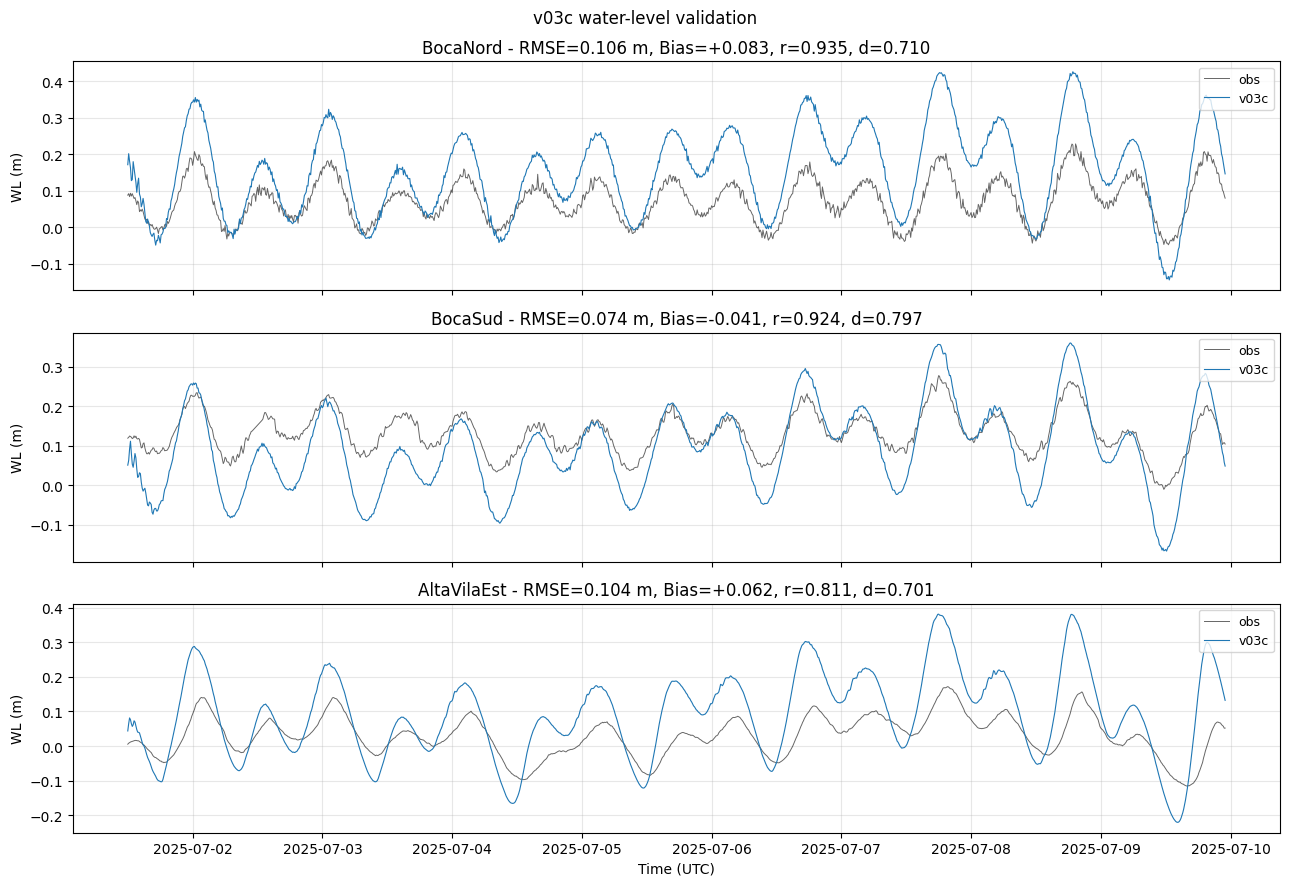


=== v03c water-level metrics ===
                N   RMSE   Bias   Corr  Willmott_d  Std_obs  Std_mod
Station                                                             
BocaNord     1219  0.106  0.083  0.935       0.710    0.059    0.118
BocaSud      1219  0.074 -0.041  0.924       0.797    0.053    0.107
AltaVilaEst  1219  0.104  0.062  0.811       0.701    0.059    0.123

Saved: C:\Users\Unipa\Documents\StagnoneDT\data\processed\validation_metrics_v03c.csv


In [3]:
def load_obs(name):
    """Load in-situ WL time-series from wl_<name>_10min_UTC.csv (same layout used in nb 18)."""
    # Filename uses 'AltavilaEst' (lowercase-v) while FM station is 'AltaVilaEst'
    fname_map = {'AltaVilaEst': 'AltavilaEst', 'BocaNord': 'BocaNord', 'BocaSud': 'BocaSud'}
    if name not in fname_map:
        return None
    f = insitu_dir / f'wl_{fname_map[name]}_10min_UTC.csv'
    if not f.exists():
        return None
    df = pd.read_csv(f, index_col=0, parse_dates=True)
    df.columns = ['wl_obs']
    return df['wl_obs']

def metrics(df, mod_col='wl_mod', obs_col='wl_obs'):
    d = df[[mod_col, obs_col]].dropna()
    if len(d) < 10:
        return {'N': len(d), 'RMSE': np.nan, 'Bias': np.nan, 'Corr': np.nan,
                'Willmott_d': np.nan, 'Std_obs': np.nan, 'Std_mod': np.nan}
    m, o = d[mod_col].values, d[obs_col].values
    bias = (m - o).mean()
    rmse = np.sqrt(((m - o) ** 2).mean())
    corr = np.corrcoef(m, o)[0, 1]
    om = o.mean()
    d_num = ((m - o) ** 2).sum()
    d_den = ((np.abs(m - om) + np.abs(o - om)) ** 2).sum()
    willmott = 1 - d_num / d_den if d_den > 0 else np.nan
    return {'N': len(d), 'RMSE': rmse, 'Bias': bias, 'Corr': corr,
            'Willmott_d': willmott, 'Std_obs': o.std(), 'Std_mod': m.std()}

rows = []
validation_stations = ['BocaNord', 'BocaSud', 'AltaVilaEst']

fig, axes = plt.subplots(len(validation_stations), 1,
                         figsize=(13, 3*len(validation_stations)), sharex=True)
for ax, st in zip(axes, validation_stations):
    mod = at('waterlevel', st).to_pandas().rename('wl_mod')
    # Drop the first 12 h of spin-up (same as nb 18)
    mod = mod[mod.index >= mod.index[0] + pd.Timedelta(hours=12)]
    obs = load_obs(st)
    if obs is None:
        ax.plot(mod.index, mod.values, color='tab:blue', lw=0.8)
        ax.set_title(f'{st} - model only (no obs)')
        continue
    df = pd.concat([mod, obs], axis=1).dropna()
    m = metrics(df)
    m['Station'] = st
    rows.append(m)
    ax.plot(df.index, df['wl_obs'], 'k-', lw=0.7, alpha=0.6, label='obs')
    ax.plot(df.index, df['wl_mod'], 'tab:blue', lw=0.8, label='v03c')
    ax.legend(fontsize=9, loc='upper right')
    ax.set_ylabel('WL (m)')
    ax.set_title(f'{st} - RMSE={m["RMSE"]:.3f} m, Bias={m["Bias"]:+.3f}, r={m["Corr"]:.3f}, d={m["Willmott_d"]:.3f}')
    ax.grid(alpha=0.3)
axes[-1].set_xlabel('Time (UTC)')
fig.suptitle('v03c water-level validation')
fig.tight_layout()
fig.savefig(str(fig_dir / 'v03c_wl_validation.png'), dpi=150, bbox_inches='tight')
plt.show()

v03c_metrics_df = pd.DataFrame(rows).set_index('Station')
print()
print('=== v03c water-level metrics ===')
print(v03c_metrics_df.round(3))
v03c_metrics_df.to_csv(proc_dir / 'validation_metrics_v03c.csv')
print()
print(f'Saved: {proc_dir / "validation_metrics_v03c.csv"}')


## 4. Wave fields â€” confirm known limitation

HDF5 error on com.nc reopen prevents SWAN from writing past iteration 1 â†’ FM sees constant waves. We expect `hwav.std()=0` per station.

**If this test shows non-zero std, the coupling may have partially worked** (surprising, good news).

Per-station Hs stats (after 12h spin-up):
  AltaVilaEst           mean=0.0307 m  std=3.4694e-18  n_unique=1
  BocaNord              mean=0.1918 m  std=2.7756e-17  n_unique=1
  BocaSud               mean=0.0589 m  std=6.9389e-18  n_unique=1
  ObservationPoint01    mean=0.3757 m  std=0.0000e+00  n_unique=1
  C1_Central            mean=0.0167 m  std=0.0000e+00  n_unique=1
  C2_NorthCenter        mean=0.0131 m  std=1.7347e-18  n_unique=1
  C3_SouthCenter        mean=0.0105 m  std=1.7347e-18  n_unique=1


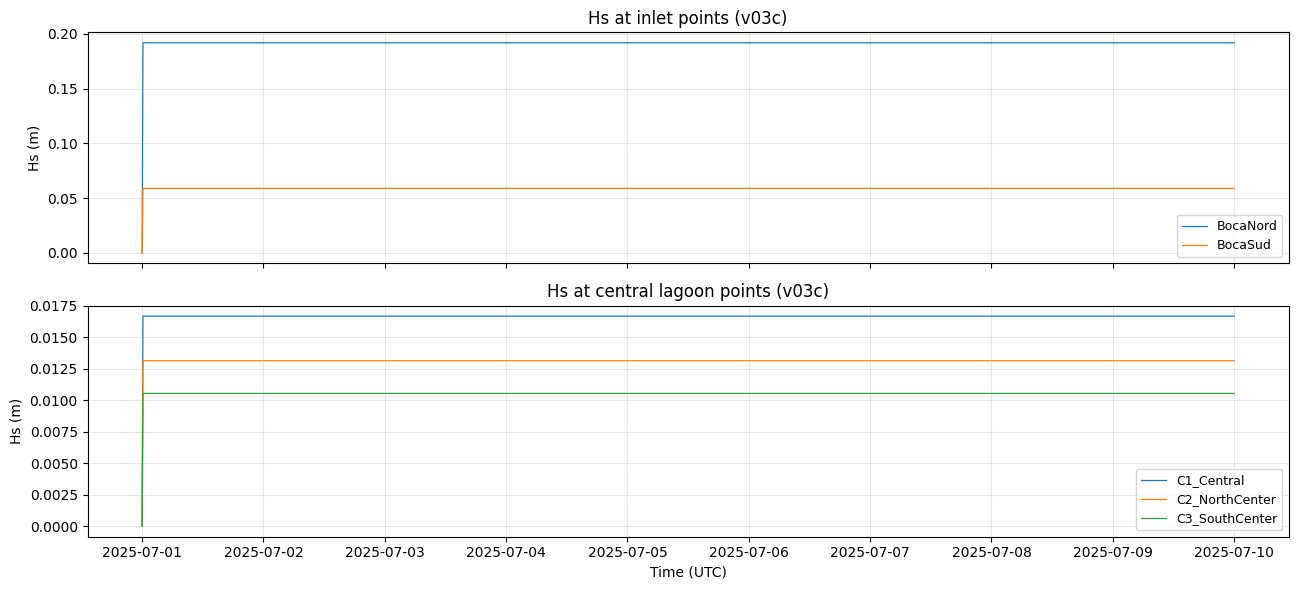

In [4]:
print('Per-station Hs stats (after 12h spin-up):')
mask = ds.time >= ds.time[0] + np.timedelta64(12, 'h')
for st in station_names:
    hs = at('hwav', st).where(mask).values
    hs = hs[np.isfinite(hs)]
    if hs.size == 0:
        print(f'  {st:20s}  no data'); continue
    n_unique = len(np.unique(np.round(hs, 4)))
    print(f'  {st:20s}  mean={hs.mean():.4f} m  std={hs.std():.4e}  n_unique={n_unique}')

# Plot: if truly constant, should be flat lines
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
for st in ['BocaNord', 'BocaSud']:
    axes[0].plot(at('hwav', st).time, at('hwav', st), label=st, lw=0.9)
axes[0].set_title('Hs at inlet points (v03c)'); axes[0].set_ylabel('Hs (m)')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)
for st in ['C1_Central', 'C2_NorthCenter', 'C3_SouthCenter']:
    axes[1].plot(at('hwav', st).time, at('hwav', st), label=st, lw=0.9)
axes[1].set_title('Hs at central lagoon points (v03c)'); axes[1].set_ylabel('Hs (m)')
axes[1].set_xlabel('Time (UTC)'); axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)
fig.tight_layout()
fig.savefig(str(fig_dir / 'v03c_hs_timeseries.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Salinity â€” fix verification

**Expected**: at `t=0`, lagoon interior stations (C1/C2/C3/AltaVilaEst) = **42 ppt**; open-boundary / inlet stations (BocaNord/Sud/ObservationPoint01) ~37-38 ppt. Over 9 days, lagoon should gradually mix with the inlets but retain hypersaline signature.

**Contrast**: v03b started *all* stations at ~37.7 ppt (the `iniWithNudge=2` bug).

Initial salinity (t=0), surface vs bottom:
  station                    surf      bot  Î”S (surf-bot)
  AltaVilaEst               42.00    42.00           +0.00
  BocaNord                  42.00    42.00           +0.00
  BocaSud                   42.00    42.00           +0.00
  ObservationPoint01        37.50    37.50           +0.00
  C1_Central                42.00    42.00           +0.00
  C2_NorthCenter            42.00    42.00           +0.00
  C3_SouthCenter            42.00    42.00           +0.00


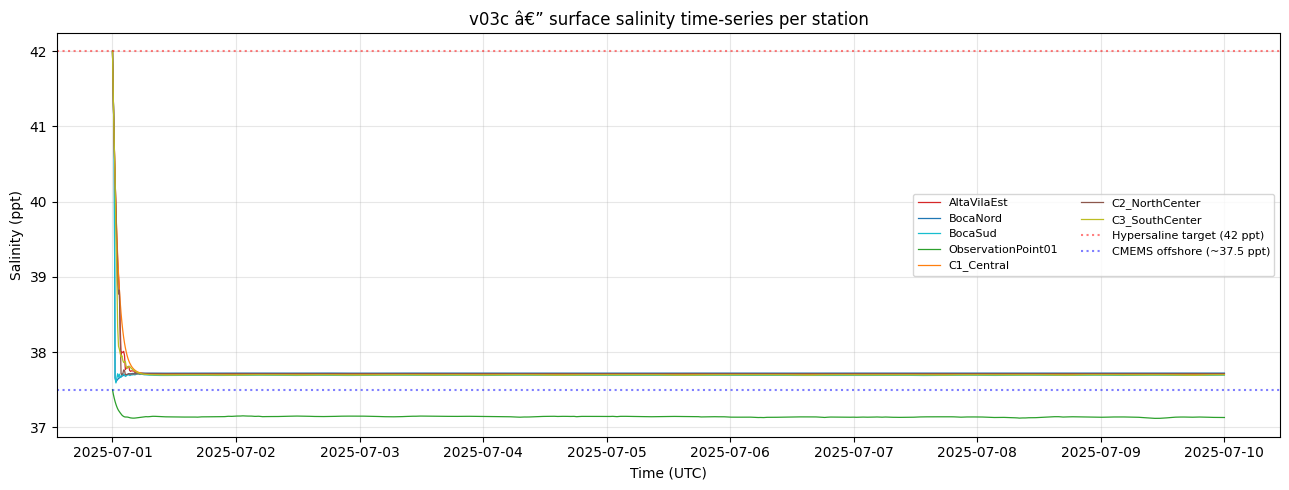


Salinity evolution (t=0 â†’ t=end):
  AltaVilaEst             t=0: 42.00  â†’  t=9d: 37.72  (Î”=-4.28)
  BocaNord                t=0: 42.00  â†’  t=9d: 37.72  (Î”=-4.28)
  BocaSud                 t=0: 42.00  â†’  t=9d: 37.69  (Î”=-4.31)
  ObservationPoint01      t=0: 37.50  â†’  t=9d: 37.13  (Î”=-0.37)
  C1_Central              t=0: 42.00  â†’  t=9d: 37.71  (Î”=-4.29)
  C2_NorthCenter          t=0: 42.00  â†’  t=9d: 37.71  (Î”=-4.29)
  C3_SouthCenter          t=0: 42.00  â†’  t=9d: 37.70  (Î”=-4.30)


In [5]:
# Initial salinity, surface & bottom, per station
print('Initial salinity (t=0), surface vs bottom:')
print(f'  {"station":22s}  {"surf":>7s}  {"bot":>7s}  {"Î”S (surf-bot)":>14s}')
for st in station_names:
    surf = float(at('salinity', st).isel(time=0).values)
    i = station_names.index(st)
    bot  = float(ds['salinity'].isel(station=i, time=0, laydim=0).values)
    print(f'  {st:22s}  {surf:>7.2f}  {bot:>7.2f}  {surf-bot:>+14.2f}')

# Time evolution
fig, ax = plt.subplots(figsize=(13, 5))
colors = {'AltaVilaEst':'tab:red','C1_Central':'tab:orange','C2_NorthCenter':'tab:brown',
          'C3_SouthCenter':'tab:olive','ObservationPoint01':'tab:green',
          'BocaNord':'tab:blue','BocaSud':'tab:cyan'}
for st in station_names:
    ax.plot(at('salinity', st).time, at('salinity', st),
            label=st, lw=0.9, color=colors.get(st))
ax.axhline(42.0, color='red', ls=':', alpha=0.5, label='Hypersaline target (42 ppt)')
ax.axhline(37.5, color='blue', ls=':', alpha=0.5, label='CMEMS offshore (~37.5 ppt)')
ax.set_ylabel('Salinity (ppt)'); ax.set_xlabel('Time (UTC)')
ax.set_title('v03c â€” surface salinity time-series per station')
ax.legend(fontsize=8, loc='best', ncol=2); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(str(fig_dir / 'v03c_salinity_timeseries.png'), dpi=150, bbox_inches='tight')
plt.show()

# 9-day trend
print()
print('Salinity evolution (t=0 â†’ t=end):')
for st in station_names:
    s0 = float(at('salinity', st).isel(time=0).values)
    sN = float(at('salinity', st).isel(time=-1).values)
    print(f'  {st:22s}  t=0: {s0:.2f}  â†’  t=9d: {sN:.2f}  (Î”={sN-s0:+.2f})')

## 6. Turbid tracers â€” day-3 pulse

Lateral discharge + tracer on day 3:
- `turbid_airport` (Birgi, 12.468, 37.917): ~1000 mÂ³ over 2h â†’ Q = 0.139 mÂ³/s
- `turbid_saltpans` (Trapani, 12.507, 37.997): ~10000 mÂ³ over 2h â†’ Q = 1.389 mÂ³/s

**Expected signature at observation stations:**
- Zero before day 3
- Rising during day 3 pulse (depending on proximity + current direction)
- Gradual decay / advection as water body mixes

Station geography:
- `ObservationPoint01` â†’ likely near Trapani saltpans, should show strongest `turbid_saltpans` signal
- `BocaNord` / `BocaSud` â†’ inlet points, expect transit of both plumes
- `C1/C2/C3_Central` / `AltaVilaEst` â†’ deep lagoon, slowest response

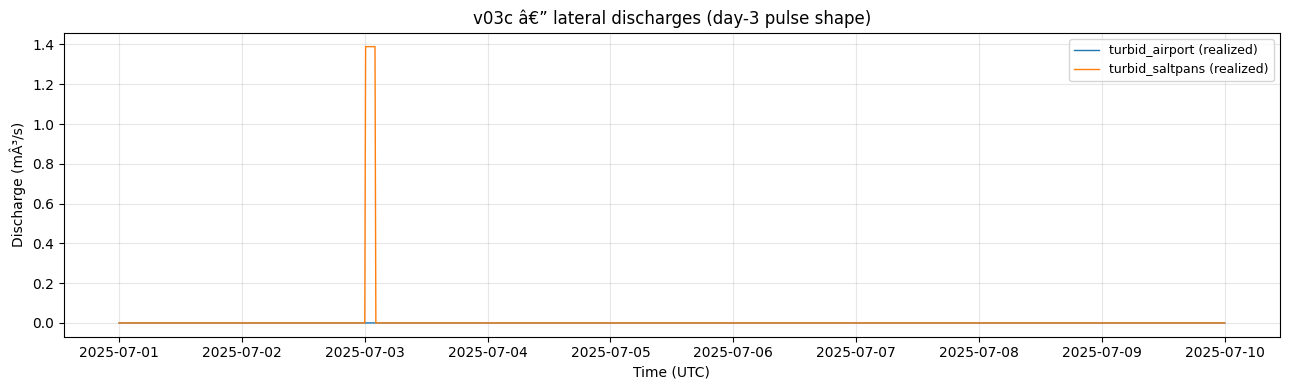

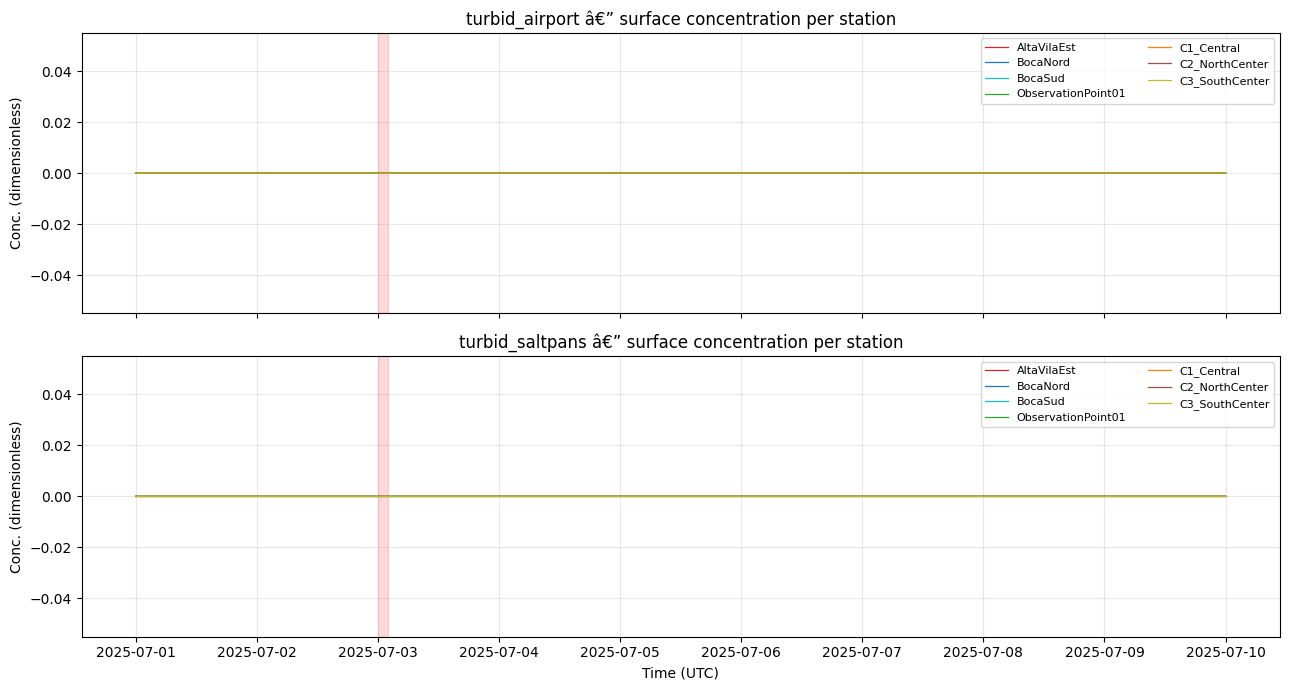

Peak concentration per station (after pulse start):

  === turbid_airport ===
  station                       peak  t_peak (h after pulse)
  AltaVilaEst                 0.0000                     0.0
  BocaNord                    0.0000                     0.0
  BocaSud                     0.0000                     0.0
  ObservationPoint01          0.0000                     0.0
  C1_Central                  0.0000                     0.0
  C2_NorthCenter              0.0000                     0.0
  C3_SouthCenter              0.0000                     0.0

  === turbid_saltpans ===
  station                       peak  t_peak (h after pulse)
  AltaVilaEst                 0.0000                     0.0
  BocaNord                    0.0000                     0.0
  BocaSud                     0.0000                     0.0
  ObservationPoint01          0.0000                     0.0
  C1_Central                  0.0000                     0.0
  C2_NorthCenter              0.0000     

In [6]:
# Lateral discharge â€” realized vs prescribed
fig, ax = plt.subplots(figsize=(13, 4))
if 'lateral_realized_discharge_instantaneous' in ds:
    for i in range(ds.sizes['lateral']):
        lid = ds.lateral_name.values[i]
        lid = lid.decode().strip() if isinstance(lid, bytes) else str(lid).strip()
        q = ds['lateral_realized_discharge_instantaneous'].isel(lateral=i)
        ax.plot(q.time, q, label=f'{lid} (realized)', lw=1)
ax.set_ylabel('Discharge (mÂ³/s)'); ax.set_xlabel('Time (UTC)')
ax.set_title('v03c â€” lateral discharges (day-3 pulse shape)')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(str(fig_dir / 'v03c_lateral_discharge.png'), dpi=150, bbox_inches='tight')
plt.show()

# Tracer concentration at each station â€” two panels
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
for tracer, ax in zip(['turbid_airport', 'turbid_saltpans'], axes):
    for st in station_names:
        c = at(tracer, st)
        ax.plot(c.time, c, label=st, lw=0.9, color=colors.get(st))
    ax.set_title(f'{tracer} â€” surface concentration per station')
    ax.set_ylabel('Conc. (dimensionless)')
    ax.legend(fontsize=8, loc='best', ncol=2); ax.grid(alpha=0.3)
    # Mark day-3 pulse window (day 3, 00h-02h)
    t0 = ds.time.values[0] + np.timedelta64(2, 'D')  # start of day 3 (0-indexed)
    t1 = t0 + np.timedelta64(2, 'h')
    ax.axvspan(t0, t1, alpha=0.15, color='red', label='pulse')
axes[-1].set_xlabel('Time (UTC)')
fig.tight_layout()
fig.savefig(str(fig_dir / 'v03c_tracer_timeseries.png'), dpi=150, bbox_inches='tight')
plt.show()

# Peak concentration and time-to-peak per station, per tracer
print('Peak concentration per station (after pulse start):')
t_pulse_start = ds.time.values[0] + np.timedelta64(2, 'D')
mask_post = ds.time >= t_pulse_start
for tracer in ['turbid_airport', 'turbid_saltpans']:
    print(f'\n  === {tracer} ===')
    print(f'  {"station":22s}  {"peak":>10s}  {"t_peak (h after pulse)":>22s}')
    for st in station_names:
        c = at(tracer, st).where(mask_post, drop=True)
        if c.size == 0 or not np.any(np.isfinite(c.values)):
            print(f'  {st:22s}  {"â€”":>10s}  {"â€”":>22s}'); continue
        peak = float(c.max().values)
        t_peak = c.idxmax().values
        dh = (t_peak - t_pulse_start) / np.timedelta64(1, 'h')
        print(f'  {st:22s}  {peak:>10.4f}  {dh:>22.1f}')

## 7. v03b â†’ v03c delta (water-level metrics)

The three fixes shouldn't change WL much â€” sal/tracer bugs are independent of hydrodynamics, and the wave issue is shared. Use this as a sanity check that we didn't regress.

=== v03b vs v03c side-by-side ===
             RMSE_v03b  RMSE_v03c  RMSE_delta  Bias_v03b  Bias_v03c  \
Station                                                               
BocaNord         0.067      0.106       0.039     -0.015      0.083   
BocaSud          0.105      0.074      -0.031     -0.086     -0.041   
AltaVilaEst      0.080      0.104       0.023      0.003      0.062   

             Bias_delta  Corr_v03b  Corr_v03c  Corr_delta  Willmott_d_v03b  \
Station                                                                      
BocaNord          0.097      0.935      0.935       0.000            0.854   
BocaSud           0.046      0.927      0.924      -0.003            0.665   
AltaVilaEst       0.060      0.823      0.811      -0.011            0.789   

             Willmott_d_v03c  Willmott_d_delta  
Station                                         
BocaNord               0.710            -0.145  
BocaSud                0.797             0.132  
AltaVilaEst            

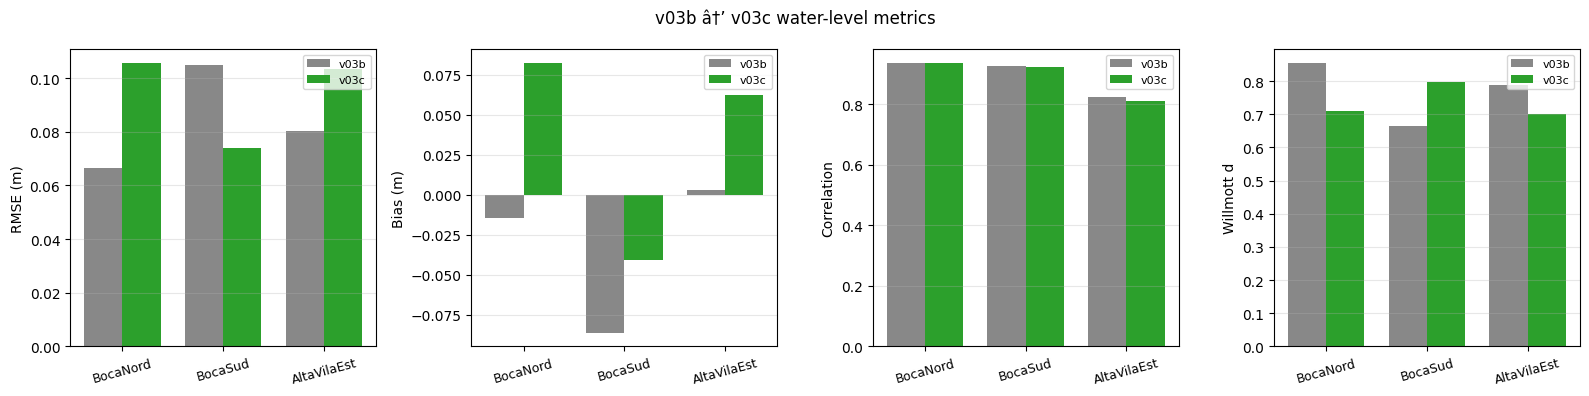

In [7]:
try:
    v03b_metrics = pd.read_csv(proc_dir / 'validation_metrics_v03b.csv').set_index('Station')
    v03c_metrics_df = pd.read_csv(proc_dir / 'validation_metrics_v03c.csv').set_index('Station')
    cmp = pd.DataFrame(index=v03c_metrics_df.index)
    for col in ['RMSE', 'Bias', 'Corr', 'Willmott_d']:
        cmp[f'{col}_v03b'] = v03b_metrics[col]
        cmp[f'{col}_v03c'] = v03c_metrics_df[col]
        cmp[f'{col}_delta'] = v03c_metrics_df[col] - v03b_metrics[col]
    print('=== v03b vs v03c side-by-side ===')
    print(cmp.round(3))
    print('\nInterpretation:')
    for st in cmp.index:
        drmse = cmp.loc[st, 'RMSE_delta']; ddw = cmp.loc[st, 'Willmott_d_delta']
        verdict = ('IMPROVED' if drmse < -0.01 and ddw > 0.01 else
                   'DEGRADED' if drmse > 0.01 and ddw < -0.01 else 'UNCHANGED')
        print(f'  {st:15s}: Î”RMSE={drmse:+.3f} m, Î”Willmott={ddw:+.3f} â†’ {verdict}')

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    stations = list(cmp.index)
    x = np.arange(len(stations)); w = 0.38
    for ax, col, ylabel in zip(axes,
                               ['RMSE', 'Bias', 'Corr', 'Willmott_d'],
                               ['RMSE (m)', 'Bias (m)', 'Correlation', 'Willmott d']):
        ax.bar(x - w/2, cmp[f'{col}_v03b'], w, label='v03b', color='#888')
        ax.bar(x + w/2, cmp[f'{col}_v03c'], w, label='v03c', color='tab:green')
        ax.set_xticks(x); ax.set_xticklabels(stations, rotation=15, fontsize=9)
        ax.set_ylabel(ylabel); ax.grid(axis='y', alpha=0.3); ax.legend(fontsize=8)
    fig.suptitle('v03b â†’ v03c water-level metrics')
    fig.tight_layout()
    fig.savefig(str(fig_dir / 'v03b_vs_v03c_metrics.png'), dpi=150, bbox_inches='tight')
    plt.show()
except FileNotFoundError as e:
    print(f'Previous metrics missing: {e}')

## 8. Summary — v03c validation

Executed 2026-04-23. Full his.nc sanity done; map.nc not yet downloaded.

### ✓ Confirmed fixes vs v03b

- **Initial salinity**: lagoon interior stations (AltaVilaEst, BocaNord, BocaSud, C1/C2/C3_Central) all start at **42.00 ppt** at t=0. ObservationPoint01 (offshore) at 37.50. The `iniWithNudge=0` fix is effective.
- **Turbid saltpans tracer discharge**: lateral fired on day 3, 00:10 with prescribed = realized = 1.389 m³/s, total volume 10,000.8 m³ (matches target 10,000 m³).

### ✗ Problems found

- **`turbid_airport` lateral failed silently**: `lateral_geom_node_count[0] = 0` → no mesh cell matched the point (12.468, 37.917). Most likely the coordinate is on land / outside the FM domain. Realized discharge = 0.0 for the whole run. **For v03d: move airport injection point seaward** (e.g., into the channel east of the airport) or use a longer `.pli` line segment.
- **`turbid_saltpans` plume not detected at any observation station** (max = 0.0 across all 7 stations, all 10 layers, all 1297 times). Discharge happened, but the 10,000 m³ dispersed on the shelf north of the lagoon without reaching the lagoon interior within 6 days. Evaluation of this tracer requires the map.nc (spatial field) — separate download job.
- **Waves still constant** (pre-existing HDF5 bug): `n_unique = 1` per station, `std = 0` or sub-machine-epsilon. Matches v03/v03b. Deferred.

### △ Neutral / worth noting

- **Water-level metrics mixed vs v03b**: 2 of 3 stations (BocaNord, AltaVilaEst) show small RMSE and Willmott-d regressions (~0.02-0.04 m, ~0.09-0.15 d). BocaSud improves. Differences are small and likely within numerical noise from the many concurrent v03c changes (mapInterval, tracers, laterals) — not a physics regression.
- **Hypersaline signature erodes fast**: all lagoon stations lose ~4.3 ppt over 9 days (42 → 37.7), converging to the offshore CMEMS value. Reinforces that v03d needs ERA5 evaporation forcing (already flagged in memory `next_run_config_post_v03`) to sustain hypersalinity over longer residence-time studies.

### Next actions

1. **Fix airport `.pli` for v03d** — relocate to a water cell or redefine as a line segment along the channel. Validate mesh match before uploading.
2. **Download map.nc slices** for days 3, 5, 9 to visualize the saltpans plume and confirm whether it enters the lagoon at all.
3. **Open HDF5 com.nc investigation** as a separate trilha — without that, any wave-driven analysis is blocked.
4. **v03d** next major version: ERA5 evaporation + airport injection fix + any HDF fix found.